# 1) Import needed Libraries ,Classes and Methods

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2) Read And Explore Data

In [2]:
sales = pd.read_csv("Sales Data.csv")
sales.head()

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


In [3]:
sales.shape

(185950, 11)

In [4]:
sales.isna().sum()

Unnamed: 0          0
Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
Month               0
Sales               0
City                0
Hour                0
dtype: int64

# 3) Data processing

### 3-1) Drop unimportant Variables (Columns)

In [5]:
sales.drop(["Unnamed: 0" ,"Order ID"] ,axis=1 ,inplace=True)

### 3-2) Features Extraction

In [6]:
# Extract Year ,Month and Day
def extract_year(date):
    return date.split()[0].split('-')[0]
def extract_month(date):
    return date.split()[0].split('-')[1]
def extract_day(date):
    return date.split()[0].split('-')[2]
    
sales["Year"] = sales['Order Date'].apply(lambda date : extract_year(date))
sales["Month"] = sales['Order Date'].apply(lambda date : extract_month(date))
sales["Day"] = sales['Order Date'].apply(lambda date : extract_day(date))

In [7]:
sales["Month"] = sales["Month"].astype(int)

In [8]:
# Extract The Street
def extract_street(address):
    return " ".join(address.split(',')[0].strip().split()[1:])
sales["Street"] = sales["Purchase Address"].apply(lambda address : extract_street(address))

In [9]:
sales.drop(["Order Date" ,"Purchase Address"] ,axis=1 ,inplace=True)

# 4) Exploratory Data Analysis EDA

In [10]:
sales.head()

,Product,Quantity Ordered,Price Each,Month,Sales,City,Hour,Year,Day,Street
0,Macbook Pro Laptop,1,1700.00,12,1700.00,New York City,0,2019,30,Church St
1,LG Washing Machine,1,600.00,12,600.00,New York City,7,2019,29,2nd St
2,USB-C Charging Cable,1,11.95,12,11.95,New York City,18,2019,12,Main St
3,27in FHD Monitor,1,149.99,12,149.99,San Francisco,15,2019,22,6th St
4,USB-C Charging Cable,1,11.95,12,11.95,Atlanta,12,2019,18,Hill St


### 4-1) Number of orders per Products

In [11]:
product_frequency = sales["Product"].value_counts()
product_frequency

Product
USB-C Charging Cable          21903
Lightning Charging Cable      21658
AAA Batteries (4-pack)        20641
AA Batteries (4-pack)         20577
Wired Headphones              18882
Apple Airpods Headphones      15549
Bose SoundSport Headphones    13325
27in FHD Monitor               7507
iPhone                         6842
27in 4K Gaming Monitor         6230
34in Ultrawide Monitor         6181
Google Phone                   5525
Flatscreen TV                  4800
Macbook Pro Laptop             4724
ThinkPad Laptop                4128
20in Monitor                   4101
Vareebadd Phone                2065
LG Washing Machine              666
LG Dryer                        646
Name: count, dtype: int64

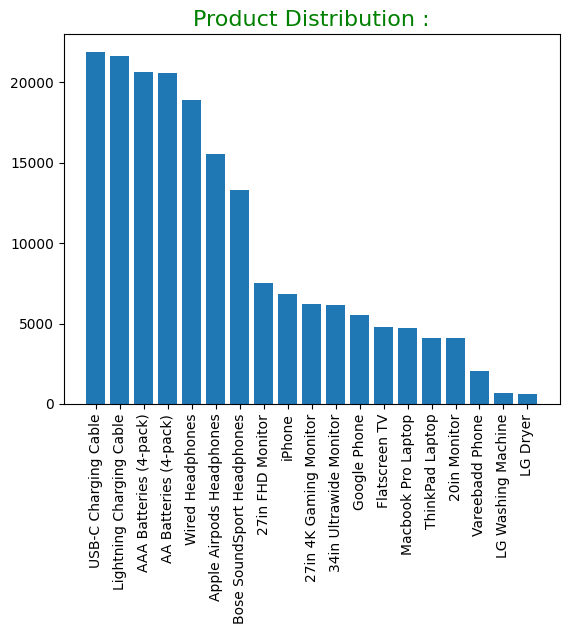

In [12]:
plt.title("Product Distribution :",fontdict={"fontsize":16 ,'color':'green'})
plt.bar(product_frequency.index ,product_frequency)
plt.xticks(rotation=90)
plt.show()

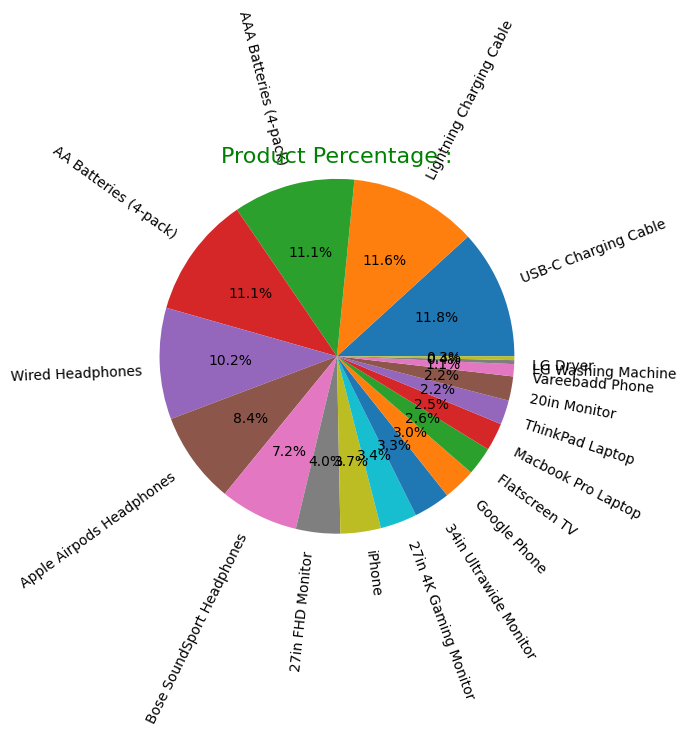

In [13]:
plt.title("Product Percentage :",fontsize=16 ,color="green")
plt.pie(product_frequency ,labels=product_frequency.index ,autopct="%1.1f%%",rotatelabels=True,radius=1.2)
#plt.legend(loc="upper left")
plt.show()

### 4-1) Order distribution per Month

In [14]:
month_frequency2019 = sales[sales["Year"]=='2019']["Month"].value_counts()
month_frequency2019.sort_index(inplace=True)
month_frequency2019

Month
1      9675
2     11975
3     15153
4     18279
5     16566
6     13554
7     14293
8     11961
9     11621
10    20282
11    17573
12    24984
Name: count, dtype: int64

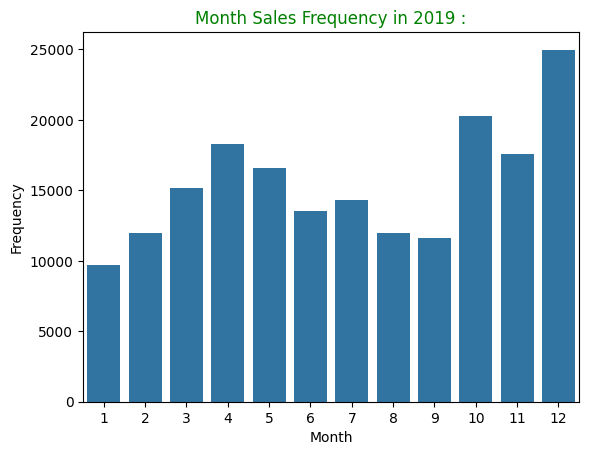

In [15]:
plt.title("Month Sales Frequency in 2019 :",color="green")
sns.barplot(x=month_frequency2019.index ,y=month_frequency2019)
plt.ylabel("Frequency")
plt.show()

In [16]:
sales.head()

,Product,Quantity Ordered,Price Each,Month,Sales,City,Hour,Year,Day,Street
0,Macbook Pro Laptop,1,1700.00,12,1700.00,New York City,0,2019,30,Church St
1,LG Washing Machine,1,600.00,12,600.00,New York City,7,2019,29,2nd St
2,USB-C Charging Cable,1,11.95,12,11.95,New York City,18,2019,12,Main St
3,27in FHD Monitor,1,149.99,12,149.99,San Francisco,15,2019,22,6th St
4,USB-C Charging Cable,1,11.95,12,11.95,Atlanta,12,2019,18,Hill St


### 4-3) Distribution of Orders by Price

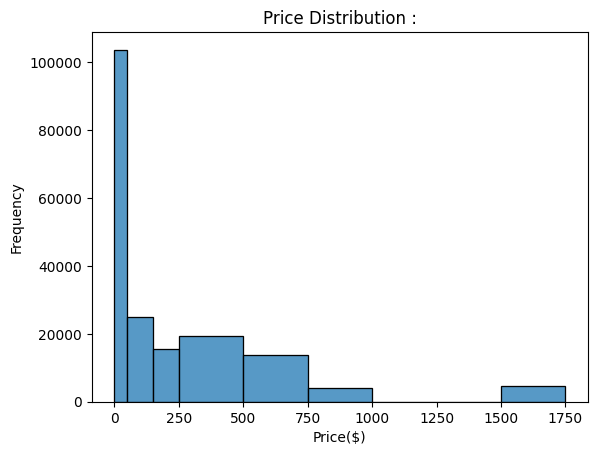

In [17]:
plt.title("Price Distribution :")
sns.histplot(data=sales ,x="Price Each",bins=[0,50,150,250,500,750 ,1000,1250 ,1500 ,1750])
plt.xlabel("Price($)")
plt.ylabel("Frequency")
plt.show()

In [18]:
city_frequency = sales["City"].value_counts()
city_frequency

City
San Francisco    44732
Los Angeles      29605
New York City    24876
Boston           19934
Atlanta          14881
Dallas           14820
Seattle          14732
Portland         12465
Austin            9905
Name: count, dtype: int64

### 4-4) Distribution of Sales of each Product per Month

In [19]:
products = sales["Product"].unique()
products

array(['Macbook Pro Laptop', 'LG Washing Machine', 'USB-C Charging Cable',
       '27in FHD Monitor', 'AA Batteries (4-pack)',
       'Bose SoundSport Headphones', 'AAA Batteries (4-pack)',
       'ThinkPad Laptop', 'Lightning Charging Cable', 'Google Phone',
       'Wired Headphones', 'Apple Airpods Headphones', 'Vareebadd Phone',
       'iPhone', '20in Monitor', '34in Ultrawide Monitor',
       'Flatscreen TV', '27in 4K Gaming Monitor', 'LG Dryer'],
      dtype=object)

In [20]:
sales_2019 = sales[sales["Year"]=='2019']
sales_2019.shape

(185916, 10)

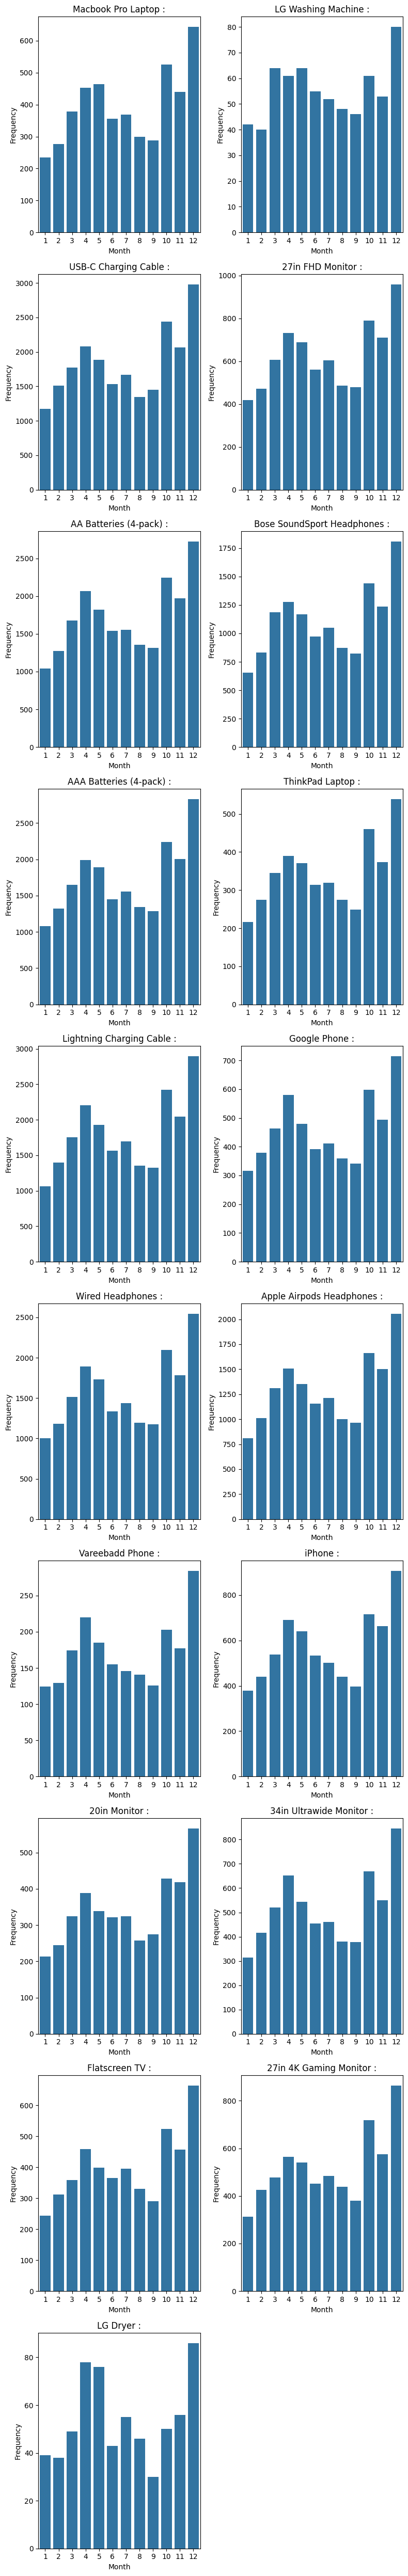

In [21]:
import math
nproducts = len(products)
ncols = 2
nrows = math.ceil(nproducts/ncols)
fig ,axes = plt.subplots(nrows ,ncols ,figsize=(8 ,5*nrows))
axes = axes.flatten()
plt.title("Products Sales in each Month :")
for i ,product in enumerate(products) :
    product_sales = sales_2019[sales_2019['Product']==product]["Month"].value_counts()
    axes[i].set_title(f"{product} :")
    axes[i].set_ylabel("Frequency")
    sns.barplot(x=product_sales.index ,y=product_sales ,ax=axes[i])
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()